# GrowthParameterEstimation quick test
Step-by-step joint fits for 20k + 30k with shared K and optional shared r.
Day 0 is forced to 67 (20k) and 100 (30k).

In [11]:
using Pkg

function ensure_pkgs(pkgs::Vector{String})
    deps = Pkg.dependencies()
    installed = Set([d.name for d in values(deps) if d.name !== nothing])
    missing = [p for p in pkgs if !(p in installed)]
    if !isempty(missing)
        Pkg.add(missing)
    end
end

pkgs = ["GrowthParameterEstimation", "CSV", "DataFrames", "OrdinaryDiffEq", "Plots", "BlackBoxOptim"]
ensure_pkgs(pkgs)
using GrowthParameterEstimation, CSV, DataFrames, OrdinaryDiffEq, Plots, Statistics, BlackBoxOptim

## Step 1: Load monoculture day-averaged data
This enforces day 0 and sets $u_0$ to 67 (20k) or 100 (30k).

In [12]:
base_dir = raw"c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Untreated MonoCulture"
u0_map = Dict("20k" => 67.0, "30k" => 100.0)

function load_day_averages(density::String, variant::String)
    file_name = variant == "naive" ? "A2780Naive_day_averages.csv" : "A2780cis_day_averages.csv"
    data_path = joinpath(base_dir, density, "Averages", file_name)
    df = CSV.read(data_path, DataFrame)
    x = Float64.(df[!, "Day"])
    y = Float64.(df[!, "Mean Cells"])
    yerr = Float64.(df[!, "SEM Cells"])  # Standard error of the mean
    u0 = u0_map[density]
    if x[1] == 0.0
        y[1] = u0
        yerr[1] = 0.0  # No error for initial condition
    else
        x = vcat(0.0, x)
        y = vcat(u0, y)
        yerr = vcat(0.0, yerr)
    end
    return x, y, yerr, u0
end

function load_both_densities(variant::String)
    x20, y20, yerr20, u020 = load_day_averages("20k", variant)
    x30, y30, yerr30, u030 = load_day_averages("30k", variant)
    return (x20, y20, yerr20, u020), (x30, y30, yerr30, u030)
end

load_both_densities (generic function with 1 method)

## Step 2: Define joint-fit models (append-only library)
Shared parameters across 20k/30k for each model. Models include logistic, general logistic (theta), Allee variants, Gompertz, and generalized Gompertz.
Add new models only via `add_model!` with a unique name.

In [20]:
epsu(x) = max(x, 1e-9)
allee(u, A) = epsu(u) / (A + epsu(u))
gompertz_term(u, K) = max(log(K / epsu(u)), 1e-9)

# --- Model library (append-only) ---
# Each model is stored by a unique name and never removed.
const MODEL_LIBRARY = Dict{String, NamedTuple}()

function add_model!(name::String; f!, p0::Vector{Float64}, bounds::Vector{Tuple{Float64,Float64}}, title::String)
    if haskey(MODEL_LIBRARY, name)
        @warn "Model already exists, keeping original" name
        return
    end
    MODEL_LIBRARY[name] = (f! = f!, p0 = p0, bounds = bounds, title = title)
end

# --- Models (add only) ---
function logistic_joint!(du, u, p, t)
    r, K = p
    du[1] = r * u[1] * (1 - (epsu(u[1]) / K))
    du[2] = r * u[2] * (1 - (epsu(u[2]) / K))
end

function theta_logistic_joint!(du, u, p, t)
    r, K, theta = p
    du[1] = r * u[1] * (1 - (epsu(u[1]) / K)^theta)
    du[2] = r * u[2] * (1 - (epsu(u[2]) / K)^theta)
end

function logistic_allee_joint!(du, u, p, t)
    r, K, A = p
    du[1] = r * u[1] * allee(u[1], A) * (1 - (epsu(u[1]) / K))
    du[2] = r * u[2] * allee(u[2], A) * (1 - (epsu(u[2]) / K))
end

function theta_logistic_allee_joint!(du, u, p, t)
    r, K, theta, A = p
    du[1] = r * u[1] * allee(u[1], A) * (1 - (epsu(u[1]) / K)^theta)
    du[2] = r * u[2] * allee(u[2], A) * (1 - (epsu(u[2]) / K)^theta)
end

function gompertz_joint!(du, u, p, t)
    r, K = p
    du[1] = r * u[1] * gompertz_term(u[1], K)
    du[2] = r * u[2] * gompertz_term(u[2], K)
end

function gompertz_allee_joint!(du, u, p, t)
    r, K, A = p
    du[1] = r * u[1] * allee(u[1], A) * gompertz_term(u[1], K)
    du[2] = r * u[2] * allee(u[2], A) * gompertz_term(u[2], K)
end

function gompertz_theta_joint!(du, u, p, t)
    r, K, theta = p
    du[1] = r * u[1] * (gompertz_term(u[1], K))^theta
    du[2] = r * u[2] * (gompertz_term(u[2], K))^theta
end

function gompertz_theta_allee_joint!(du, u, p, t)
    r, K, theta, A = p
    du[1] = r * u[1] * allee(u[1], A) * (gompertz_term(u[1], K))^theta
    du[2] = r * u[2] * allee(u[2], A) * (gompertz_term(u[2], K))^theta
end

function logistic_death_joint!(du, u, p, t)
    r, K, d = p
    du[1] = r * u[1] * (1 - (epsu(u[1]) / K)) - d * u[1]
    du[2] = r * u[2] * (1 - (epsu(u[2]) / K)) - d * u[2]
end

function theta_logistic_death_joint!(du, u, p, t)
    r, K, theta, d = p
    du[1] = r * u[1] * (1 - (epsu(u[1]) / K)^theta) - d * u[1]
    du[2] = r * u[2] * (1 - (epsu(u[2]) / K)^theta) - d * u[2]
end

add_model!("logistic_shared_rk";
    f! = logistic_joint!,
    p0 = [0.2, 1000.0],
    bounds = [(0.0, 2.0), (100.0, 40000.0)],
    title = "LOGISTIC"
 )

add_model!("logistic_death_shared_rk";
    f! = logistic_death_joint!,
    p0 = [0.2, 1000.0, 0.01],
    bounds = [(0.0, 2.0), (100.0, 40000.0), (0.0, 0.5)],
    title = "LOGISTIC + DEATH"
 )

add_model!("logistic_allee_shared_rk";
    f! = logistic_allee_joint!,
    p0 = [0.2, 1000.0, 100.0],
    bounds = [(0.0, 2.0), (100.0, 40000.0), (1.0, 5000.0)],
    title = "LOGISTIC + ALLEE"
 )

add_model!("theta_logistic_shared_rk";
    f! = theta_logistic_joint!,
    p0 = [0.2, 1000.0, 1.0],
    bounds = [(0.0, 2.0), (100.0, 40000.0), (0.5, 5.0)],
    title = "THETA-LOGISTIC (GENERAL LOGISTIC)"
 )

add_model!("theta_logistic_allee_shared_rk";
    f! = theta_logistic_allee_joint!,
    p0 = [0.2, 1000.0, 1.0, 100.0],
    bounds = [(0.0, 2.0), (100.0, 40000.0), (0.5, 5.0), (1.0, 5000.0)],
    title = "THETA-LOGISTIC + ALLEE"
 )

add_model!("general_logistic_shared_rk";
    f! = theta_logistic_joint!,
    p0 = [0.2, 1000.0, 1.0],
    bounds = [(0.0, 2.0), (100.0, 40000.0), (0.5, 5.0)],
    title = "GENERAL LOGISTIC (RICHARDS)"
 )

add_model!("general_logistic_death_shared_rk";
    f! = theta_logistic_death_joint!,
    p0 = [0.2, 1000.0, 1.0, 0.01],
    bounds = [(0.0, 2.0), (100.0, 40000.0), (0.5, 5.0), (0.0, 0.5)],
    title = "GENERAL LOGISTIC + DEATH"
 )

add_model!("general_logistic_allee_shared_rk";
    f! = theta_logistic_allee_joint!,
    p0 = [0.2, 1000.0, 1.0, 100.0],
    bounds = [(0.0, 2.0), (100.0, 40000.0), (0.5, 5.0), (1.0, 5000.0)],
    title = "GENERAL LOGISTIC + ALLEE"
 )

add_model!("gompertz_shared_rk";
    f! = gompertz_joint!,
    p0 = [0.2, 1000.0],
    bounds = [(0.0, 2.0), (100.0, 40000.0)],
    title = "GOMPERTZ"
 )

add_model!("gompertz_allee_shared_rk";
    f! = gompertz_allee_joint!,
    p0 = [0.2, 1000.0, 100.0],
    bounds = [(0.0, 2.0), (100.0, 40000.0), (1.0, 5000.0)],
    title = "GOMPERTZ + ALLEE"
 )

add_model!("gompertz_theta_shared_rk";
    f! = gompertz_theta_joint!,
    p0 = [0.2, 1000.0, 1.0],
    bounds = [(0.0, 2.0), (100.0, 40000.0), (0.5, 5.0)],
    title = "GENERALIZED GOMPERTZ"
 )

add_model!("gompertz_theta_allee_shared_rk";
    f! = gompertz_theta_allee_joint!,
    p0 = [0.2, 1000.0, 1.0, 100.0],
    bounds = [(0.0, 2.0), (100.0, 40000.0), (0.5, 5.0), (1.0, 5000.0)],
    title = "GENERALIZED GOMPERTZ + ALLEE"
 )

function bic_from_sse(sse, n, k)
    return n * log(sse / n) + k * log(n)
end

function fit_joint(x20, y20, yerr20, u020, x30, y30, yerr30, u030; model_name::String, normalize_loss::Bool=true)
    @assert haskey(MODEL_LIBRARY, model_name) "Unknown model: $model_name"
    model = MODEL_LIBRARY[model_name]
    f! = model.f!
    k_guess = max(maximum(y20), maximum(y30)) * 1.2
    p0 = copy(model.p0)
    if length(p0) >= 2
        p0[2] = k_guess
    end
    bounds = model.bounds

    tspan = (min(minimum(x20), minimum(x30)), max(maximum(x20), maximum(x30)))
    prob = ODEProblem(f!, [u020, u030], tspan, p0)
    save_times = sort(unique(vcat(x20, x30)))

    loss_raw = function(p)
        sol = solve(remake(prob, p=p), Tsit5(); saveat=save_times)
        pred20 = [sol(t)[1] for t in x20]
        pred30 = [sol(t)[2] for t in x30]
        return sum(abs2.(y20 .- pred20)) + sum(abs2.(y30 .- pred30))
    end

    loss_norm = function(p)
        sol = solve(remake(prob, p=p), Tsit5(); saveat=save_times)
        pred20 = [sol(t)[1] for t in x20]
        pred30 = [sol(t)[2] for t in x30]
        return sum(abs2.((y20 .- pred20) ./ epsu.(y20))) + sum(abs2.((y30 .- pred30) ./ epsu.(y30)))
    end

    loss_used = normalize_loss ? loss_norm : loss_raw
    res = bboptimize(loss_used; SearchRange=bounds, MaxTime=20.0, TraceMode=:silent)
    p_best = best_candidate(res)
    sol = solve(remake(prob, p=p_best), Tsit5(); saveat=save_times)
    sse_raw = loss_raw(p_best)
    sse_norm = loss_norm(p_best)
    n = length(x20) + length(x30)
    bic = bic_from_sse(sse_raw, n, length(p_best))
    return p_best, sol, sse_raw, sse_norm, bic
end

function plot_joint(x20, y20, x30, y30, sol; title_str="")
    p = scatter(x20, y20; label="20k data", markersize=4, xlabel="Day", ylabel="Cells", title=title_str)
    scatter!(p, x30, y30; label="30k data", markersize=4)
    tgrid = sol.t
    pred20 = getindex.(sol.u, 1)
    pred30 = getindex.(sol.u, 2)
    plot!(p, tgrid, pred20; label="20k fit", linewidth=2)
    plot!(p, tgrid, pred30; label="30k fit", linewidth=2)
    display(p)
end

function models_for_variant(variant::String)
    return [
        "logistic_shared_rk",
        "logistic_death_shared_rk",
        "logistic_allee_shared_rk",
        "theta_logistic_shared_rk",
        "theta_logistic_allee_shared_rk",
        "general_logistic_shared_rk",
        "general_logistic_death_shared_rk",
        "general_logistic_allee_shared_rk",
        "gompertz_shared_rk",
        "gompertz_allee_shared_rk",
        "gompertz_theta_shared_rk",
        "gompertz_theta_allee_shared_rk"
    ]
end

function run_joint_model(variant::String; model_name::String, normalize_loss::Bool=true)
    (x20, y20, yerr20, u020), (x30, y30, yerr30, u030) = load_both_densities(variant)
    p, sol, sse_raw, sse_norm, bic = fit_joint(x20, y20, yerr20, u020, x30, y30, yerr30, u030; model_name=model_name, normalize_loss=normalize_loss)
    title_str = MODEL_LIBRARY[model_name].title * " - " * variant
    plot_joint(x20, y20, x30, y30, sol; title_str=title_str)
    return (model=model_name, params=p, sse_raw=sse_raw, sse_norm=sse_norm, bic=bic)
end

run_joint_model (generic function with 1 method)

## Step 3: Run joint fits + BIC comparison
Fits all models for naive and resistant with shared parameters across 20k/30k.
Outputs a results table and BIC bar charts per cell line.

Row,cell_line,model,title,params,sse_raw,sse_norm,bic
,String,String,String,String,Float64,Float64,Float64
1,naive,logistic_shared_rk,LOGISTIC,"[0.8725, 3947.9117]",1.0705e6,0.488874,321.276
2,naive,general_logistic_shared_rk,GENERAL LOGISTIC (RICHARDS),"[0.9659, 4045.2644, 0.7241]",9.98323e5,0.471936,322.583
3,naive,theta_logistic_shared_rk,THETA-LOGISTIC (GENERAL LOGISTIC),"[0.9659, 4045.2644, 0.7241]",9.98323e5,0.471936,322.583
4,naive,logistic_death_shared_rk,LOGISTIC + DEATH,"[0.951, 4302.9791, 0.0785]",1.0705e6,0.488874,324.677
5,naive,logistic_allee_shared_rk,LOGISTIC + ALLEE,"[0.8761, 3945.3947, 1.0]",1.07888e6,0.49388,324.911
6,naive,general_logistic_death_shared_rk,GENERAL LOGISTIC + DEATH,"[1.0518, 4550.044, 0.7241, 0.0858]",9.98323e5,0.471936,325.984
7,naive,theta_logistic_allee_shared_rk,THETA-LOGISTIC + ALLEE,"[0.9764, 4047.8009, 0.7115, 1.0]",1.00154e6,0.475122,326.08
8,naive,general_logistic_allee_shared_rk,GENERAL LOGISTIC + ALLEE,"[0.9764, 4047.8009, 0.7115, 1.0]",1.00154e6,0.475122,326.08
9,naive,gompertz_theta_shared_rk,GENERALIZED GOMPERTZ,"[0.4983, 3871.5479, 0.5135]",1.37531e6,0.459058,332.193


Row,cell_line,model,title,params,sse_raw,sse_norm,bic
,String,String,String,String,Float64,Float64,Float64
1,naive,logistic_shared_rk,LOGISTIC,"[0.8725, 3947.9117]",1.0705e6,0.488874,321.276
2,resistant,general_logistic_allee_shared_rk,GENERAL LOGISTIC + ALLEE,"[0.6847, 3745.8627, 2.4976, 118.9306]",2.71292e6,1.75798,397.869


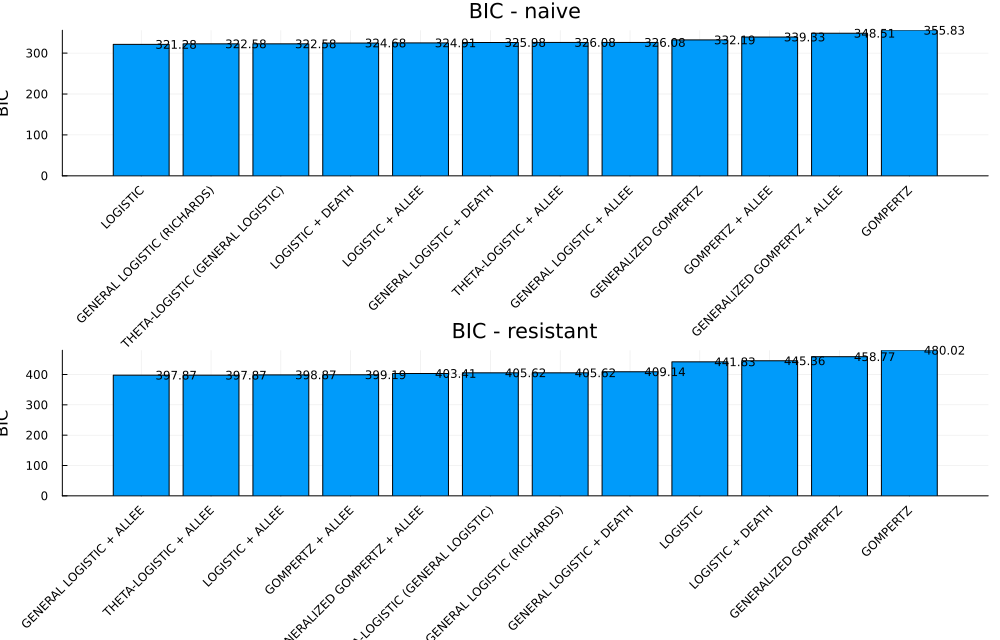


Best model per cell line:


In [21]:
using Dates

output_dir = joinpath(@__DIR__, "outputs")
mkpath(output_dir)
results_csv = joinpath(output_dir, "monoculture_model_bic_results.csv")
best_csv = joinpath(output_dir, "monoculture_best_models.csv")

normalize_loss = true
results = if isfile(results_csv)
    println("Loading cached results from: ", results_csv)
    CSV.read(results_csv, DataFrame)
else
    variants = ["naive", "resistant"]
    tmp = DataFrame(cell_line=String[], model=String[], title=String[], params=String[], sse_raw=Float64[], sse_norm=Float64[], bic=Float64[])
    for v in variants
        (d20, d30) = load_both_densities(v)
        model_names = models_for_variant(v)
        for m in model_names
            p, sol, sse_raw, sse_norm, bic = fit_joint(d20..., d30...; model_name=m, normalize_loss=normalize_loss)
            push!(tmp, (
                cell_line=v,
                model=m,
                title=MODEL_LIBRARY[m].title,
                params=string(round.(p; digits=4)),
                sse_raw=sse_raw,
                sse_norm=sse_norm,
                bic=bic
            ))
        end
    end
    CSV.write(results_csv, tmp)
    tmp
end

results_sorted = sort(results, [:cell_line, :bic])
display(results_sorted)

best_rows = combine(groupby(results_sorted, :cell_line)) do sdf
    sdf[1, :]
end
CSV.write(best_csv, best_rows)
println("\nBest model per cell line:")
display(best_rows)

function plot_bic_bars(df::DataFrame)
    cell_lines = unique(df.cell_line)
    plots = Any[]
    for cl in cell_lines
        sub = sort(df[df.cell_line .== cl, :], :bic)
        labels = sub.title
        p = bar(labels, sub.bic; title="BIC - $cl", legend=false, xrotation=45, xlabel="Model", ylabel="BIC")
        for (i, b) in enumerate(sub.bic)
            annotate!(p, i, b, text(string(round(b; digits=2)), :center, 8))
        end
        push!(plots, p)
    end
    display(plot(plots...; layout=(length(plots), 1), size=(1000, 320 * length(plots))))
end

plot_bic_bars(results_sorted)

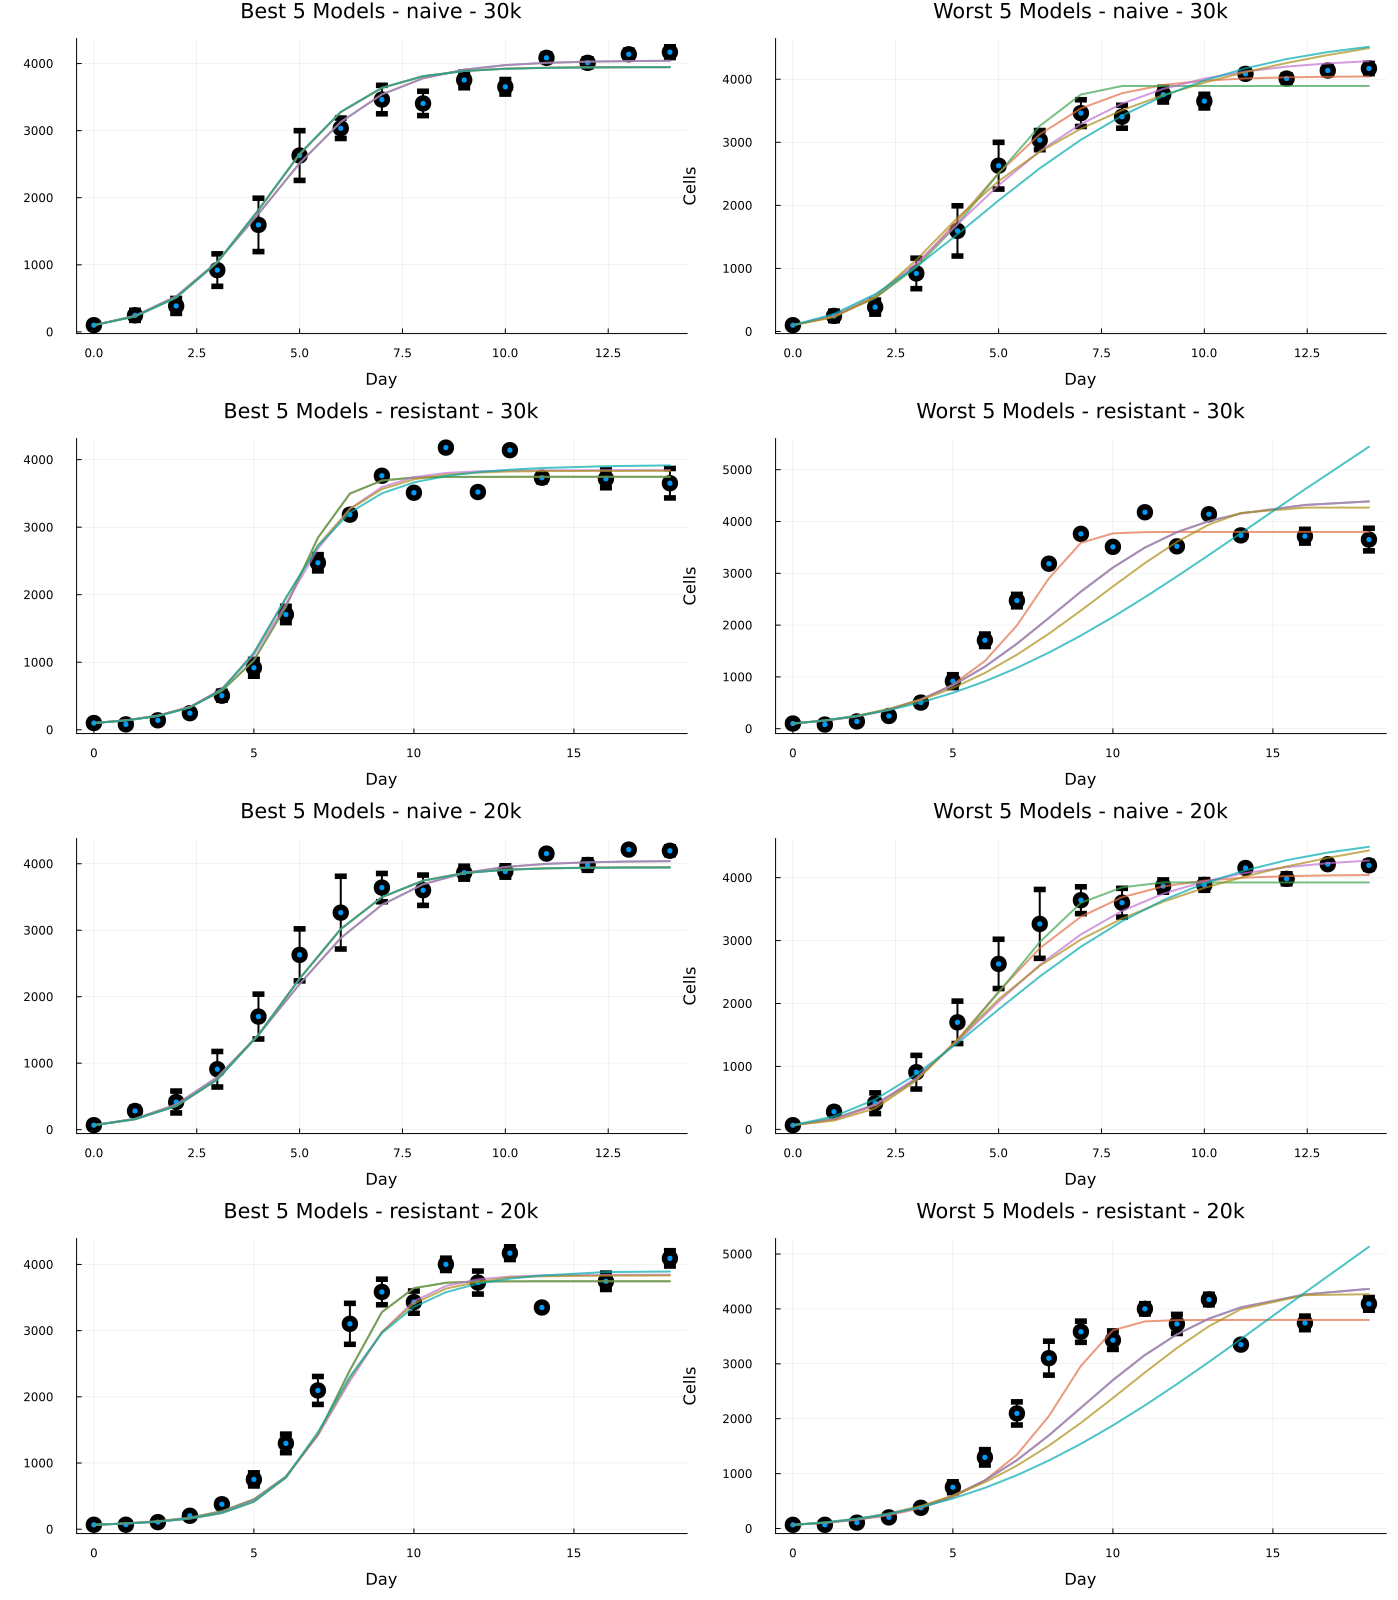

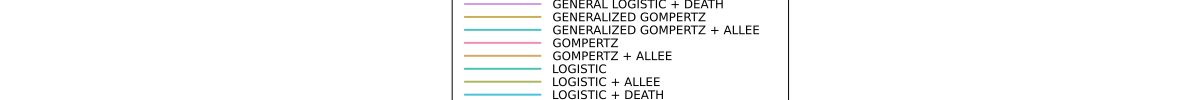

In [22]:
# Plot model fits from saved CSV (no refit)
results_csv = joinpath(@__DIR__, "outputs", "monoculture_model_bic_results.csv")
@assert isfile(results_csv) "Missing results CSV: $results_csv"
results_csv_df = CSV.read(results_csv, DataFrame)

function parse_params(s::AbstractString)
    t = replace(s, '[' => "", ']' => "")
    parts = split(t, ',')
    return [parse(Float64, strip(p)) for p in parts if !isempty(strip(p))]
end

function plot_fits_from_csv(cell_line::String; density::String)
    (d20, d30) = load_both_densities(cell_line)
    (x20, y20, yerr20, u020) = d20
    (x30, y30, yerr30, u030) = d30
    x = density == "20k" ? x20 : x30
    y = density == "20k" ? y20 : y30
    yerr = density == "20k" ? yerr20 : yerr30
    u0 = density == "20k" ? u020 : u030

    sub = sort(results_csv_df[results_csv_df.cell_line .== cell_line, :], :bic)
    
    # Split into best 5 and worst 5
    best5 = sub[1:min(5, nrow(sub)), :]
    worst5 = sub[max(1, nrow(sub)-4):nrow(sub), :]
    
    # Plot best 5
    title_best = "Best 5 Models - $(cell_line) - $(density)"
    plt_best = scatter(x, y; yerror=yerr, label="data", markersize=6, markerstrokewidth=2, xlabel="Day", ylabel="Cells", title=title_best, legend=false)
    
    for row in eachrow(best5)
        model_name = row.model
        p = parse_params(row.params)
        f! = MODEL_LIBRARY[model_name].f!
        tspan = (minimum(x), maximum(x))
        prob = ODEProblem(f!, [u020, u030], tspan, p)
        sol = solve(prob, Tsit5(); saveat=x)
        pred = density == "20k" ? getindex.(sol.u, 1) : getindex.(sol.u, 2)
        plot!(plt_best, x, pred; label=row.title, linewidth=2, alpha=0.7)
    end
    
    # Plot worst 5
    title_worst = "Worst 5 Models - $(cell_line) - $(density)"
    plt_worst = scatter(x, y; yerror=yerr, label="data", markersize=6, markerstrokewidth=2, xlabel="Day", ylabel="Cells", title=title_worst, legend=false)
    
    for row in eachrow(worst5)
        model_name = row.model
        p = parse_params(row.params)
        f! = MODEL_LIBRARY[model_name].f!
        tspan = (minimum(x), maximum(x))
        prob = ODEProblem(f!, [u020, u030], tspan, p)
        sol = solve(prob, Tsit5(); saveat=x)
        pred = density == "20k" ? getindex.(sol.u, 1) : getindex.(sol.u, 2)
        plot!(plt_worst, x, pred; label=row.title, linewidth=2, alpha=0.7)
    end
    
    return plt_best, plt_worst
end

# Generate all 8 plots (4 environments × 2 plots each)
naive30_best, naive30_worst = plot_fits_from_csv("naive"; density="30k")
resistant30_best, resistant30_worst = plot_fits_from_csv("resistant"; density="30k")
naive20_best, naive20_worst = plot_fits_from_csv("naive"; density="20k")
resistant20_best, resistant20_worst = plot_fits_from_csv("resistant"; density="20k")

# Combine all plots with shared legend at bottom
all_plots = [naive30_best, naive30_worst, resistant30_best, resistant30_worst, 
             naive20_best, naive20_worst, resistant20_best, resistant20_worst]

# Create a dummy plot for the legend
legend_labels = vcat(["data"], sort(results_csv_df[results_csv_df.cell_line .== "naive", :].title))
legend_plot = plot(legend=:inside, framestyle=:none, showaxis=false, grid=false, size=(1200, 100))
for (i, lbl) in enumerate(legend_labels)
    if lbl == "data"
        scatter!(legend_plot, [NaN], [NaN]; label=lbl, markersize=6, markerstrokewidth=2)
    else
        plot!(legend_plot, [NaN], [NaN]; label=lbl, linewidth=2, alpha=0.7)
    end
end

display(plot(all_plots...; layout=(4, 2), size=(1400, 1600)))
display(legend_plot)